<a href="https://colab.research.google.com/github/himanshira/Natural-Language-Processing/blob/main/NLP_Topic_Analysis_of_Review_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Problem Statement
###A popular mobile phone brand, XYZ, has launched its budget smartphone in the Indian market. The client wants to understand the voice of the customer (VOC) on the product. This will be useful to not just evaluate thecurrent product but also to get some direction for developing the product pipeline. The client is particularly interested in the different aspects that the customers care about. Product reviews by customers on a leading e-commerce site should provide a good amount of data.

In [ ]:
#!pip install gensim

##Import Libraries

In [ ]:
import re
import string
import gensim
from collections import Counter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# 3. Tokenize the reviews using NLTK's word_tokenize function

import nltk
from gensim.models import LdaModel
from gensim.models import CoherenceModel
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet

from gensim import corpora

In [ ]:
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

###Task 1. Read the .csv file using Pandas, and look at the first few top records

In [ ]:
review_df = pd.read_csv('/content/drive/MyDrive/Simplilearn/NLP/K8 Reviews v0.2.csv')

In [ ]:
review_df

,sentiment,review
0,1,Good but need updates and improvements
1,0,"Worst mobile i have bought ever, Battery is dr..."
2,1,when I will get my 10% cash back.... its alrea...
3,1,Good
4,0,The worst phone everThey have changed the last...
...,...,...
14670,1,"I really like the phone, Everything is working..."
14671,1,The Lenovo K8 Note is awesome. It takes best p...
14672,1,Awesome Gaget.. @ this price
14673,1,This phone is nice processing will be successf...


In [ ]:
review_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14675 entries, 0 to 14674
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   sentiment  14675 non-null  int64 
 1   review     14675 non-null  object
dtypes: int64(1), object(1)
memory usage: 229.4+ KB


###Task 2. Normalize the casing of the review text, and extract the text into alist for easier manipulation.

In [ ]:
review_df['review'] = review_df['review'].str.lower()
review_list = review_df['review'].tolist()

print("Dataframe after lowercasing\n")
print(review_df)
print('-'*70)
print('-'*70)
print("\nList of reviews\n")
print(review_list)

Dataframe after lowercasing

       sentiment                                             review
0              1             good but need updates and improvements
1              0  worst mobile i have bought ever, battery is dr...
2              1  when i will get my 10% cash back.... its alrea...
3              1                                               good
4              0  the worst phone everthey have changed the last...
...          ...                                                ...
14670          1  i really like the phone, everything is working...
14671          1  the lenovo k8 note is awesome. it takes best p...
14672          1                       awesome gaget.. @ this price
14673          1  this phone is nice processing will be successf...
14674          1      good product but the pakeging was not enough.

[14675 rows x 2 columns]
----------------------------------------------------------------------
----------------------------------------------------------

### Task 3. Punctuation and Number Removal Step

In [ ]:
cleaned_reviews = []

for review_text in review_list:
  clean_text = re.sub(r'[^a-z\s]', '', review_text)
  clean_text = re.sub(r'\s+', ' ', clean_text).strip()
  cleaned_reviews.append(clean_text)

print("Cleaned Reviews after punctuation and number removal:")
print(cleaned_reviews)

Cleaned Reviews after punctuation and number removal:
['good but need updates and improvements', 'worst mobile i have bought ever battery is draining like hell backup is only to hours with internet uses even if i put mobile idle its getting dischargedthis is biggest lie from amazon lenove which is not at all expected they are making full by saying that battery is mah booster charger is fake it takes at least to hours to be fully chargeddont know how lenovo will survive by making full of usplease dont go for this else you will regret like me', 'when i will get my cash back its already january', 'good', 'the worst phone everthey have changed the last phone but the problem is still same and the amazon is not returning the phone highly disappointing of amazon', 'only im telling dont buyim totally disappointedpoor batterypoor camerawaste of money', 'phone is awesome but while charging it heats up allotreally a genuine reason to hate lenovo k note', 'the battery level has worn down', 'its ov

###Task 4. Tokenize the reviews using NLTK's word_tokenize function


In [ ]:
review_tokens = [word_tokenize(review_text) for review_text in cleaned_reviews]
print("Review Tokens (after cleaning and tokenization):")
print(review_tokens)

Review Tokens (after cleaning and tokenization):
[['good', 'but', 'need', 'updates', 'and', 'improvements'], ['worst', 'mobile', 'i', 'have', 'bought', 'ever', 'battery', 'is', 'draining', 'like', 'hell', 'backup', 'is', 'only', 'to', 'hours', 'with', 'internet', 'uses', 'even', 'if', 'i', 'put', 'mobile', 'idle', 'its', 'getting', 'dischargedthis', 'is', 'biggest', 'lie', 'from', 'amazon', 'lenove', 'which', 'is', 'not', 'at', 'all', 'expected', 'they', 'are', 'making', 'full', 'by', 'saying', 'that', 'battery', 'is', 'mah', 'booster', 'charger', 'is', 'fake', 'it', 'takes', 'at', 'least', 'to', 'hours', 'to', 'be', 'fully', 'chargeddont', 'know', 'how', 'lenovo', 'will', 'survive', 'by', 'making', 'full', 'of', 'usplease', 'dont', 'go', 'for', 'this', 'else', 'you', 'will', 'regret', 'like', 'me'], ['when', 'i', 'will', 'get', 'my', 'cash', 'back', 'its', 'already', 'january'], ['good'], ['the', 'worst', 'phone', 'everthey', 'have', 'changed', 'the', 'last', 'phone', 'but', 'the', 'p

###Task 5. Perform parts-of-speech tagging on each sentence using the NLTK POS tagger

In [ ]:
tagged_reviews = [nltk.pos_tag(tokens) for tokens in review_tokens]

print("\nPOS Tagged Reviews:")
print(tagged_reviews)

###Task 6. For the topic model, include nouns only
      


In [ ]:
# a. Find all POS tags that correspond to nouns

def pos_tagger(nltk_tag):
  if  nltk_tag.startswith('J'):
    return wordnet.ADJ
  elif nltk_tag.startswith('V'):
    return wordnet.VERB
  elif nltk_tag.startswith('N'):
    return wordnet.NOUN
  elif nltk_tag.startswith('R'):
    return wordnet.ADV
  else:
    return wordnet.NOUN


###Task 7. Lemmatize

In [ ]:
#--- Initialize lemmatizer ---

lemmatizer = WordNetLemmatizer()

#--- a. The different forms of the terms need to be treated as one ---

processed_reviews_for_topic_model = []

for review_idx, tagged_review in enumerate(tagged_reviews):
  lemmatized_nouns_in_review = []
  for word, tag in tagged_review:
    if tag.startswith('N'):
      wn_tag = pos_tagger(tag)
      lemmatized_word = lemmatizer.lemmatize(word, pos=wn_tag)
      lemmatized_nouns_in_review.append(lemmatized_word)
  processed_reviews_for_topic_model.append(lemmatized_nouns_in_review)

print("\nProcessed Reviews (Nouns Only, Lemmatized, after Punctuation/Number removal):")
print(processed_reviews_for_topic_model)


Processed Reviews (Nouns Only, Lemmatized, after Punctuation/Number removal):
[['update', 'improvement'], ['mobile', 'i', 'battery', 'hell', 'backup', 'hour', 'internet', 'us', 'idle', 'dischargedthis', 'lie', 'amazon', 'lenove', 'battery', 'booster', 'charger', 'hour', 'dont'], ['i', 'cash'], [], ['phone', 'everthey', 'phone', 'problem', 'amazon', 'phone', 'amazon'], ['im', 'buyim', 'camerawaste', 'money'], ['phone', 'reason', 'k', 'note'], ['battery', 'level'], ['hitting', 'problemsand', 'phone', 'problem', 'k', 'noteso', 'station', 'year', 'phone', 'lenovo'], ['lot', 'glitch', 'thing', 'option'], ['wrost'], ['phone', 'charger', 'damage', 'month'], ['purchase', 'item', 'battery', 'life'], ['i', 'battery', 'problem', 'motherboard', 'problem', 'month', 'mobile', 'life'], ['phone', 'slim', 'battry', 'backup', 'screen'], ['headset'], ['time', 'i'], ['product', 'prize', 'range', 'specification', 'comparison', 'mobileunder', 'range', 'i', 'phone', 'seal', 'i', 'credit', 'card', 'i', 'deal

###Task 8. Remove stopwords

In [ ]:
# Convert to set for faster lookup

stp_wrds_eng = set(stopwords.words('english'))

#--- b. Remove stopwords ---

final_processed_reviews = []
for review_word_list in processed_reviews_for_topic_model:
  filtered_words = [word for word in review_word_list if word not in stp_wrds_eng]
  final_processed_reviews.append(filtered_words)

print("\nFinal Processed Reviews (Nouns Only, Lemmatized, Stopwords removed):")
print(final_processed_reviews)


Final Processed Reviews (Nouns Only, Lemmatized, Stopwords removed):
[['update', 'improvement'], ['mobile', 'battery', 'hell', 'backup', 'hour', 'internet', 'us', 'idle', 'dischargedthis', 'lie', 'amazon', 'lenove', 'battery', 'booster', 'charger', 'hour', 'dont'], ['cash'], [], ['phone', 'everthey', 'phone', 'problem', 'amazon', 'phone', 'amazon'], ['im', 'buyim', 'camerawaste', 'money'], ['phone', 'reason', 'k', 'note'], ['battery', 'level'], ['hitting', 'problemsand', 'phone', 'problem', 'k', 'noteso', 'station', 'year', 'phone', 'lenovo'], ['lot', 'glitch', 'thing', 'option'], ['wrost'], ['phone', 'charger', 'damage', 'month'], ['purchase', 'item', 'battery', 'life'], ['battery', 'problem', 'motherboard', 'problem', 'month', 'mobile', 'life'], ['phone', 'slim', 'battry', 'backup', 'screen'], ['headset'], ['time'], ['product', 'prize', 'range', 'specification', 'comparison', 'mobileunder', 'range', 'phone', 'seal', 'credit', 'card', 'deal', 'amazon'], ['battery', 'dont', 'solution'

In [ ]:
total_reviews = len(final_processed_reviews)
print(f"Total number of reviews in the processed reviews are {total_reviews} ")

Total number of reviews in the processed reviews are 14675 


###Task 9. Create a topic model using LDA on the cleaned-up data with 12 topics


In [ ]:
#--- Create a dictionary that maps unique word to an int ID ---

dictionary = gensim.corpora.dictionary.Dictionary(final_processed_reviews)

#--- Filter out the less appearing words in the document ---

dictionary.filter_extremes(no_below=5, no_above=0.5, keep_n=100000 )

#--- Create a Bag of Words Representation so that it converts list of lists to
#--- word_id and word_count ---

bow_corpus = [dictionary.doc2bow(rev) for rev in final_processed_reviews]

#--- View a few word mapping with print statement ---

print("\n--- Gensim Dictionary for the first 20 words in the corpus ---\n")
print(list(dictionary.items())[:20])

#--- View a few BOW documents from Gensim Corpus ---

print("\n--- Gensim Corpus for the first document in the BOW corpus ---\n")
print(bow_corpus[0])


--- Gensim Dictionary for the first 20 words in the corpus ---

[(0, 'improvement'), (1, 'update'), (2, 'amazon'), (3, 'backup'), (4, 'battery'), (5, 'booster'), (6, 'charger'), (7, 'dont'), (8, 'hell'), (9, 'hour'), (10, 'idle'), (11, 'internet'), (12, 'lie'), (13, 'mobile'), (14, 'us'), (15, 'cash'), (16, 'phone'), (17, 'problem'), (18, 'im'), (19, 'money')]

--- Gensim Corpus for the first document in the BOW corpus ---

[(0, 1), (1, 1)]


In [ ]:
# Train the LDA (Linear Discriminant Analysis) model

num_topics = 12
lda_model = LdaModel(corpus=bow_corpus,
                     id2word=dictionary,
                     num_topics=num_topics,
                     random_state=100,
                     update_every=1,
                     chunksize=100,
                     passes=10,
                     alpha='auto',
                     per_word_topics=True)


### a. Print the top terms for each topic

In [ ]:
print("\n--- Top terms for each topic and their keywords ---\n")
for idx, topic in lda_model.print_topics(-1):
  print(f"Topic: {idx} Words: {topic}\n")


--- Top terms for each topic and their keywords ---

Topic: 0 Words: 0.308*"price" + 0.097*"sim" + 0.050*"slot" + 0.050*"star" + 0.048*"look" + 0.045*"box" + 0.041*"refund" + 0.029*"r" + 0.028*"ok" + 0.023*"ko"

Topic: 1 Words: 0.326*"problem" + 0.118*"heating" + 0.085*"update" + 0.083*"dont" + 0.078*"software" + 0.057*"please" + 0.051*"work" + 0.027*"worth" + 0.019*"way" + 0.016*"mi"

Topic: 2 Words: 0.154*"mobile" + 0.138*"k" + 0.095*"feature" + 0.083*"lenovo" + 0.031*"delivery" + 0.026*"bit" + 0.024*"h" + 0.023*"hai" + 0.020*"game" + 0.018*"dolby"

Topic: 3 Words: 0.179*"performance" + 0.073*"speaker" + 0.056*"everything" + 0.052*"video" + 0.045*"drain" + 0.040*"superb" + 0.030*"front" + 0.027*"image" + 0.027*"touch" + 0.025*"expectation"

Topic: 4 Words: 0.707*"product" + 0.087*"lot" + 0.039*"killer" + 0.038*"nothing" + 0.020*"suggestion" + 0.017*"redmi" + 0.013*"complain" + 0.010*"vibe" + 0.009*"dnt" + 0.009*"hence"

Topic: 5 Words: 0.628*"phone" + 0.032*"processor" + 0.024*"musi

###Explanation of the above output-

*   The top 12 topics are printed out with the probability for each word within a specific topic.





#### b. Find the coherence of the model with the c_v metric

In [ ]:
print("\n--- Calculating Coherence Score ---\n")
coherence_model = CoherenceModel(model=lda_model, texts=final_processed_reviews, dictionary=dictionary, coherence='c_v')
coherence_model_score = coherence_model.get_coherence()
print(f"Coherence Score: {coherence_model_score}")


--- Calculating Coherence Score ---

Coherence Score: 0.44850648950705435


#**Coherence Score Observation**

### The coherence score for a topic model measures the degree of semantic similarity between high-scoring words in the topic.
### High coherence means top words in the topic co-occur frequently and are much more meaningful for humans being interpretable for them.


### Our model is moderately good with a score of **0.4485**

#**Task 10. Analyze the topics through the business lens**


## **Topicwise breakdown**

1. With a score of .308 being the highest probability for price in **topic 0**, it can be assumed that customer has emphasized more on price in their review. "sim" + *"slot" + "look" + "box" + "refund" indicates the customer may not be happy after unboxing the item reasons might be sim slot and the overall look and might like a refund.
2. Topic 1 is indicative of the of the heating problem and the word "mi" here suggest the Red-mi phone.

3. Topic 2 suggests that the review is about the mobile phone and its features

4. Topic 3 suggests that the review is about the performance and multimedia tech specs of the device.

5. Topic 4 can be interpreted as strongly positive with the word "killer", the "nothing" and "complain" suggest negative or neutral review,

6. Topic 5 talks about the fundamental aspects of using a smartphone.

7. Topic 6 is about lacking the phone storage.

8. Topic 7 has keywords like "network", "month", "hour", "device", "charger", "heat", "waste", "return", "handset", "turbo" which means the phone is heating and the user would likely return the item.

9. A general discussion about battery life is happening in topic 8.

10. The discussion in topic 9 surrounds the Camera & Audio Quality.

11. Phone Software & Design details are being discussed in topic 10

12. Topic 11 focusses on Customer Service & Online Retailer Experience.


#**a. Determine which of the topics can be combined**

## The topics that have issues or problems with phone like topic 0, topic 11 and topic 1 can be combined. The items that have performance issues like topic 3 and topic 5 can be combined

#Task 11. Create a topic model using LDA with what you think is the optimal number of topics


In [ ]:
#--- Create dictionary and corpus ---

dictionary = corpora.Dictionary(final_processed_reviews)

#--- Set filter_extremes to remove noise. Make it restrictive for larger dataset  ---

dictionary.filter_extremes(no_below=1, no_above=0.9, keep_n=100000)

corpus = [dictionary.doc2bow(rev) for rev in final_processed_reviews]


print("\n--- Gensim Dictionary for the first 20 words in the corpus ---\n")
print(list(dictionary.items())[:20])

print("\n--- Gensim Corpus for the first document in the BOW corpus ---\n")
print(corpus[0])


--- Gensim Dictionary for the first 20 words in the corpus ---

[(0, 'improvement'), (1, 'update'), (2, 'amazon'), (3, 'backup'), (4, 'battery'), (5, 'booster'), (6, 'charger'), (7, 'dischargedthis'), (8, 'dont'), (9, 'hell'), (10, 'hour'), (11, 'idle'), (12, 'internet'), (13, 'lenove'), (14, 'lie'), (15, 'mobile'), (16, 'us'), (17, 'cash'), (18, 'everthey'), (19, 'phone')]

--- Gensim Corpus for the first document in the BOW corpus ---

[(0, 1), (1, 1)]


In [ ]:
#--- Find optimal number of topics ---

min_topics = 2
max_topics = 15
step_topics = 1

coherence_scores = []
model_list = []
topic_nums = []

print("\n--- Training LDA Model and Calculating Coherence Score ---\n")
for num_topics in range(min_topics, max_topics + 1, step_topics):
  print(f"\n--- Training LDA model with {num_topics}.... ")
  lda_model = LdaModel(corpus=corpus,
                       id2word=dictionary,
                       num_topics=num_topics,
                       random_state=100,
                       update_every=1,
                       chunksize=100,
                       passes=10,
                       alpha='auto',
                       per_word_topics=True)
  model_list.append(lda_model)
  topic_nums.append(num_topics)
  coherence_model = CoherenceModel(model=lda_model,
                                   texts=final_processed_reviews,
                                   dictionary=dictionary,
                                   coherence='c_v')
  coherence_score = coherence_model.get_coherence()
  coherence_scores.append(coherence_score)
  print(f"  Coherence Score for {num_topics} topics: {coherence_score:.4f}")


--- Training LDA Model and Calculating Coherence Score ---


--- Training LDA model with 2.... 
  Coherence Score for 2 topics: 0.5999

--- Training LDA model with 3.... 
  Coherence Score for 3 topics: 0.5722

--- Training LDA model with 4.... 
  Coherence Score for 4 topics: 0.5526

--- Training LDA model with 5.... 
  Coherence Score for 5 topics: 0.5050

--- Training LDA model with 6.... 
  Coherence Score for 6 topics: 0.5011

--- Training LDA model with 7.... 
  Coherence Score for 7 topics: 0.4973

--- Training LDA model with 8.... 
  Coherence Score for 8 topics: 0.4727

--- Training LDA model with 9.... 
  Coherence Score for 9 topics: 0.4665

--- Training LDA model with 10.... 
  Coherence Score for 10 topics: 0.4506

--- Training LDA model with 11.... 
  Coherence Score for 11 topics: 0.4727

--- Training LDA model with 12.... 
  Coherence Score for 12 topics: 0.4517

--- Training LDA model with 13.... 
  Coherence Score for 13 topics: 0.4549

--- Training LDA model with 14


--- Plotting Coherence Scores ---


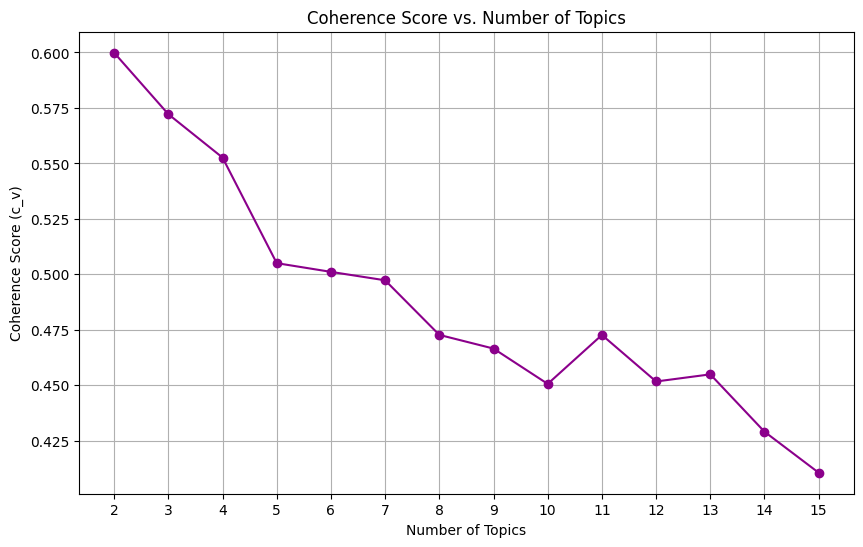

In [ ]:
print("\n--- Plotting Coherence Scores ---\n")
plt.figure(figsize=(10, 6))
plt.plot(topic_nums, coherence_scores, marker='o', linestyle='-', color='darkmagenta')
plt.xlabel("Number of Topics")
plt.ylabel("Coherence Score (c_v)")
plt.title("Coherence Score vs. Number of Topics")
plt.xticks(topic_nums)
plt.grid(True)
plt.show()

In [ ]:
#--- Find the topic number with the highest coherence score ---

optimal_num_topics = topic_nums[np.argmax(coherence_scores)]
max_coherence = np.max(coherence_scores)

print(f'Optimal number of topics: {optimal_num_topics} (with Coherence scores of {max_coherence})')

Optimal number of topics: 2 (with Coherence scores of 0.5998703963392538)


###Task 12. Businesses should be able to interpret the topics.


In [ ]:
# a. Name each of the identified topics
optimal_model_index = topic_nums.index(optimal_num_topics)
optimal_lda_model = model_list[optimal_model_index]

print(f"\n--- Top terms for the Optimal Topic Model ({optimal_num_topics} topics) ---\n")
topics_terms = optimal_lda_model.print_topics(num_words=10) # Get top 10 terms for each topic
for idx, topic_info in topics_terms:
    print(f"Topic {idx}: {topic_info}")


--- Top terms for the Optimal Topic Model (2 topics) ---
Topic 0: 0.095*"phone" + 0.043*"camera" + 0.038*"battery" + 0.028*"product" + 0.020*"problem" + 0.019*"mobile" + 0.018*"issue" + 0.018*"quality" + 0.013*"time" + 0.013*"day"
Topic 1: 0.062*"k" + 0.057*"note" + 0.026*"screen" + 0.023*"call" + 0.015*"option" + 0.014*"sim" + 0.011*"g" + 0.011*"h" + 0.010*"hai" + 0.009*"support"


In [ ]:
#--- Name Each Topic and Prepare for Table ---

topic_names_and_terms = []

for idx, topic_info in topics_terms:
  if idx == 0:
    topic_name='Product Quality & Customer Satisfaction'
  elif idx == 1:
    topic_name='Product Features & Customer Support'
  else:
    topic_name = f'Topic {idx} is Unassigned.'

  topic_names_and_terms.append({"Topic Name": topic_name,
                                "Top 10 Terms": topic_info})

In [ ]:
# b. Create a table with the topic names and the top ten terms in each to present to the business

print("\n--- Business Report- Key Topics for Customer Reviews ---\n")
print("| Topic Name                                 | Top 10 Terms (and their weights)                                |")
print("|--------------------------------------------|-----------------------------------------------------------------|")
for item in topic_names_and_terms:
  print(f"| {item['Topic Name'].ljust(42)} | {item['Top 10 Terms'].ljust(63)} |")


--- Business Report- Key Topics for Customer Reviews ---

| Topic Name                                 | Top 10 Terms (and their weights)                                |
|--------------------------------------------|-----------------------------------------------------------------|
| Product Quality & Customer Satisfaction    | 0.095*"phone" + 0.043*"camera" + 0.038*"battery" + 0.028*"product" + 0.020*"problem" + 0.019*"mobile" + 0.018*"issue" + 0.018*"quality" + 0.013*"time" + 0.013*"day" |
| Product Features & Customer Support        | 0.062*"k" + 0.057*"note" + 0.026*"screen" + 0.023*"call" + 0.015*"option" + 0.014*"sim" + 0.011*"g" + 0.011*"h" + 0.010*"hai" + 0.009*"support" |


In [ ]:
#--- Create a Table using DataFrame ---
print("\n\t--- Business Report: Key Topics from Customer Reviews (DataFrame) ---")
LDA_Topic_Table = pd.DataFrame(topic_names_and_terms)
LDA_Topic_Table


	--- Business Report: Key Topics from Customer Reviews (DataFrame) ---


,Topic Name,Top 10 Terms
0,Product Quality & Customer Satisfaction,"0.095*""phone"" + 0.043*""camera"" + 0.038*""batter..."
1,Product Features & Customer Support,"0.062*""k"" + 0.057*""note"" + 0.026*""screen"" + 0...."
